In [436]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

<div style="background-color:#FFF5E1; text-align:center; padding:30px; border-radius:10px; margin-bottom:30px;">
    <h1 style="color:#0C1844; font-size:40px; font-weight:bold; margin:0;">
        🚀 Shipping Performance Analysis for E-commerce
    </h1> <br><br><br>
    <p style="margin-bottom: 0;">
        A data-driven analysis using the Brazilian Olist E-commerce dataset to identify the key drivers of delivery delays. <br>

Delivery delays are common problem in modern e-commerce. This could lead to customer dissatisfaction and losing customers in a long term. Therefore, it's best to identify indicators that led to shipping delays and the data could be used in decision-making to prevent further delays.<br>

There are many factors that could contribute to the delays such as location of the sellers, product category, payment type, seller history performance and so forth.<br>

In this dataset, we will discover what would be the underlying factors.
    </p>
</div>

<div style="background-color:#FF6969; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h2 style="color:#FFF5E1; font-size:28px; margin:0;">
        🧩 1. Data Cleaning
    </h2>
</div>


In [437]:
# Import all the dataset
orders = pd.read_csv("Datasets/olist_orders_dataset.csv")
customers = pd.read_csv('Datasets/olist_customers_dataset.csv')
geolocation = pd.read_csv('Datasets/olist_geolocation_dataset.csv')
order_items = pd.read_csv('Datasets/olist_order_items_dataset.csv')
payments = pd.read_csv('Datasets/olist_order_payments_dataset.csv')
reviews = pd.read_csv('Datasets/olist_order_reviews_dataset.csv')
products = pd.read_csv('Datasets/olist_products_dataset.csv')
sellers = pd.read_csv('Datasets/olist_sellers_dataset.csv')
categories=pd.read_csv('Datasets/product_category_name_translation.csv')

In [438]:
dfs = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "geolocation": geolocation,
    "categories": categories
}
for name, df in dfs.items():
    print(f"\n{name.upper()} - NULL values:")
    print(df.isnull().sum(),'\n')


ORDERS - NULL values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 


ORDER_ITEMS - NULL values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 


PAYMENTS - NULL values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64 


REVIEWS - NULL values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64 



In [439]:
for name, df in dfs.items():
    print(f"\n{name.upper()} - Duplicates: {df.duplicated().sum()}")


ORDERS - Duplicates: 0

ORDER_ITEMS - Duplicates: 0

PAYMENTS - Duplicates: 0

REVIEWS - Duplicates: 0

CUSTOMERS - Duplicates: 0

SELLERS - Duplicates: 0

PRODUCTS - Duplicates: 0

GEOLOCATION - Duplicates: 261831

CATEGORIES - Duplicates: 0


<div style="background-color:#FF6969; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h3 style="color:#FFF5E1; font-size:24px; margin:0;">
        1.1 Handling Duplicates
    </h3>
</div>

<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">There are 261831 duplicated values foudn at Geolocation table.</li>
             <li style="margin-bottom: 6px;">Remove duplicated values to make the table clean and concise also make the process run smoother.</li>
        </ul>
    </div>
    </p>
</div>


In [440]:
geolocation.duplicated(subset=['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']).value_counts()

False    738332
True     261831
dtype: int64

In [441]:
geolocation = geolocation.drop_duplicates()
geolocation.duplicated().sum()

0

<div style="background-color:#FF6969; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h3 style="color:#FFF5E1; font-size:24px; margin:0;">
         1.2 Handling Missing Data
    </h3>
</div>

<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
        Orders Table
    </h4>
</div>

In [442]:
# Take an overview look at the main table
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [443]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [444]:
cols_to_datetime = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders[cols_to_datetime] = orders[cols_to_datetime].apply(pd.to_datetime)
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [445]:
orders[['order_delivered_customer_date','order_estimated_delivery_date']].isnull().sum()

order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">It seems there are many orders without customers delivery date. Next we will take a look at what kinds of orders are lacking this information. </li>      
        </ul>
    </div>
    </p>
</div>

In [446]:
null_delivery = orders['order_delivered_customer_date'].isnull()
orders[null_delivery].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07


In [447]:
orders[null_delivery]['order_status'].value_counts()

shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: order_status, dtype: int64

<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
       <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">Some of the orders don't have <b>order_delivered_customer_date</b> because they were either approved,shipped or processed so it's reasonable from logistics standpoint.</li>
            <li style="margin-bottom: 6px;">The same applies for 'Cancelled' and 'Unavailable' orders. </li>
            <li style="margin-bottom: 6px;">However There are 8 orders without <b>order_delivered_customer_date</b> but marked as 'delivered'. Next we will investigate this case.</li>
        </ul>
    </div>
    </p>
</div>

In [448]:
delivered_order_null_date = orders[null_delivery & (orders["order_status"] == "delivered")]['order_id'].values
delivered_order_null_date

array(['2d1e2d5bf4dc7227b3bfebb81328c15f',
       'f5dd62b788049ad9fc0526e3ad11a097',
       '2ebdfc4f15f23b91474edf87475f108e',
       'e69f75a717d64fc5ecdfae42b2e8e086',
       '0d3268bad9b086af767785e3f0fc0133',
       '2d858f451373b04fb5c984a1cc2defaf',
       'ab7c89dc1bf4a1ead9d6ec1ec8968a84',
       '20edc82cf5400ce95e1afacc25798b31'], dtype=object)

In [449]:
payments[payments["order_id"].isin(list(delivered_order_null_date))]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
7536,0d3268bad9b086af767785e3f0fc0133,1,credit_card,4,204.62
10251,20edc82cf5400ce95e1afacc25798b31,1,credit_card,1,54.97
16949,2d1e2d5bf4dc7227b3bfebb81328c15f,1,credit_card,3,134.83
28032,2ebdfc4f15f23b91474edf87475f108e,1,credit_card,3,158.07
47287,2d858f451373b04fb5c984a1cc2defaf,1,credit_card,4,194.00
58017,e69f75a717d64fc5ecdfae42b2e8e086,1,credit_card,1,158.07
95941,f5dd62b788049ad9fc0526e3ad11a097,1,debit_card,1,354.24
102958,ab7c89dc1bf4a1ead9d6ec1ec8968a84,1,credit_card,5,120.12


<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
       <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
           <li style="margin-bottom: 6px;">It is marked as 'Delivered' in order status 
But the orders don't have the delivery date to customers which make these records unreliable. So we have to remove those records</li>
        </ul>
    </div>
    </p>
</div>

In [450]:
orders = orders[~orders["order_id"].isin(list(delivered_order_null_date))].copy()
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

In [451]:
orders[orders["order_approved_at"].isnull()]["order_status"].value_counts()

canceled     141
delivered     14
created        5
Name: order_status, dtype: int64

In [452]:
no_approved_delivered = orders[orders["order_approved_at"].isnull() & (orders["order_status"] == "delivered")]["order_id"].values
no_approved_delivered

array(['e04abd8149ef81b95221e88f6ed9ab6a',
       '8a9adc69528e1001fc68dd0aaebbb54a',
       '7013bcfc1c97fe719a7b5e05e61c12db',
       '5cf925b116421afa85ee25e99b4c34fb',
       '12a95a3c06dbaec84bcfb0e2da5d228a',
       'c1d4211b3dae76144deccd6c74144a88',
       'd69e5d356402adc8cf17e08b5033acfb',
       'd77031d6a3c8a52f019764e68f211c69',
       '7002a78c79c519ac54022d4f8a65e6e8',
       '2eecb0d85f281280f79fa00f9cec1a95',
       '51eb2eebd5d76a24625b31c33dd41449',
       '88083e8f64d95b932164187484d90212',
       '3c0b8706b065f9919d0505d3b3343881',
       '2babbb4b15e6d2dfe95e2de765c97bce'], dtype=object)

<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
       <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">There are also orders who are not approved but already delivered.
Which meant they don't have to be approved.
So we include the order purchase timestamp as their approval time instead.</li>
            <li style="margin-bottom: 6px;"><b>Delivered_carrier_date</b> can also be null as it is assumed the site will deliver directly to the customers without delivering it to the carrier.</li>
            <li style="margin-bottom: 6px;">When the order is progressing like with the order status = progress, shipped, or cancelled, or unavailable, it makes sense that the <b>order_delivered_customer_date</b> can be NULL</li>
        </ul>
    </div>
    </p>
</div>

In [453]:
orders.loc[orders['order_approved_at'].isnull() & (orders['order_status'] == 'delivered'), 'order_approved_at'] = orders['order_purchase_timestamp']

In [454]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 146
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

In [455]:
orders[(orders["order_delivered_carrier_date"].isnull()) & (orders["order_status"] == "delivered")]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14


In [456]:
orders[orders['order_status']=='canceled']['order_delivered_customer_date'].isnull().sum()

619

In [457]:
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
        Reviews Table
    </h4>
</div>

In [458]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">As from the initial exploration, we know that <b>review_comment_title</b> has 87656 null values. 
This field doesn't contribute to our analysis so we will drop it</li>
        </ul>
        </ul>
    </div>
    </p>
</div>

In [459]:
reviews = reviews.drop('review_comment_title',axis=1)
reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='object')

<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
        Products Table
    </h4>
</div>

In [460]:
products = products.drop(['product_name_lenght', 'product_description_lenght', 'product_photos_qty'], axis=1)

products['product_category_name'] = products['product_category_name'].fillna('unknown')
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())

<div style="background-color:#FFF5E1; padding:20px 30px; 
    border-left: 5px groove #C80036;
    border-radius:10px; margin:40px 0;">
    <h2 style="font-size:24px;">📌 Actions Summary:</h2>
    <ul style="font-size:16px;">
        <li>The records at the orders table have a lot of null values for approval timestamp or customer delivery date timestamp. However as it is investigated, many records have the statuses in between the creation of orders and the delivery time, hence, it is logical that the columns are null.</li>
        <li>Geolocation data has many duplications for locations which we reduced the duplication to transform it to a viable master data table.</li>
    </ul>
</div>


<div style="background-color:#FF6969; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h2 style="color:#FFF5E1; font-size:28px; margin:0;">
        🤝 2. Data Merging
    </h2>
</div>


In [461]:
orders = orders.merge(customers,how='left',on='customer_id')

In [462]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [463]:
orders = orders.merge(order_items[['order_id','product_id','seller_id','price']],how='left',on='order_id')

In [464]:
orders = orders.merge(products[['product_id', 'product_category_name']], how='left', on='product_id')

orders = orders.merge(payments[['order_id', 'payment_type', 'payment_value', 'payment_installments']], how='left', on='order_id')

In [465]:
orders = orders.merge(categories,on='product_category_name')

In [466]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1204
order_delivered_customer_date    2487
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_id                          0
seller_id                           0
price                               0
product_category_name               0
payment_type                        3
payment_value                       3
payment_installments                3
product_category_name_english       0
dtype: int64

In [467]:
orders[orders['payment_type'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,product_category_name,payment_type,payment_value,payment_installments,product_category_name_english
67936,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,beleza_saude,NaN,NaN,NaN,health_beauty
67937,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,beleza_saude,NaN,NaN,NaN,health_beauty
67938,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,beleza_saude,NaN,NaN,NaN,health_beauty


<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">Those above orders have NA payment type but they were delivered and have valid delivery date to customer and estimated delivery date which are important to our analysis. So those records won't be dropped.

</li>
        </ul>
        </ul>
    </div>
    </p>
</div>

In [468]:
orders.loc[orders['payment_type'].isna(),'payment_type'] = 'not_defined'

In [469]:
orders['payment_type'].value_counts()

credit_card    85516
boleto         22542
voucher         6155
debit_card      1657
not_defined        3
Name: payment_type, dtype: int64

In [470]:
reviews.head()

,review_id,order_id,review_score,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [471]:
orders = orders.merge(reviews[['review_id','order_id','review_score','review_creation_date']],how='left',on='order_id')

In [472]:
geolocation.value_counts()

geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  geolocation_city  geolocation_state
1001                         -23.551427       -46.634074       sao paulo         SP                   1
44890                        -11.685867       -41.770145       canarana          BA                   1
                             -11.685656       -41.772517       canarana          BA                   1
                             -11.685258       -41.770865       canarana          BA                   1
                             -11.685186       -41.769463       canarana          BA                   1
                                                                                                     ..
15775                        -20.196736       -50.927601       santa fe do sul   SP                   1
                             -20.196718       -50.930722       santa fe do sul   SP                   1
                             -20.196544       -50.925540       santa 

<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">It seems one city can have multiple geolocation_lat and geolocation_lng, so we need to clean up this information before merging the table.

</li>
        </ul>
        </ul>
    </div>
    </p>
</div>



In [473]:
geo_avg = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

orders = orders.merge(geo_avg, how='left', left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix')

orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1212
order_delivered_customer_date    2507
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_id                          0
seller_id                           0
price                               0
product_category_name               0
payment_type                        0
payment_value                       3
payment_installments                3
product_category_name_english       0
review_id                         964
review_score                      964
review_creation_date              964
geolocation_zip_code_prefix       311
geolocation_lat                   311
geolocation_lng                   311
dtype: int64

<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">It seems we have a significant number of cities which don't have geolocation_lat and geolocation_lng. So we have to find median values of each city to fill up the NA values of those locations.
</li>
        </ul>
        </ul>
    </div>
    </p>
</div>


In [474]:
# use transform to preserve the original dataframe shape so we can easy fillin na later.
median_coords = orders.groupby('customer_city')[['geolocation_lat','geolocation_lng']].transform('median')
orders[['geolocation_lat', 'geolocation_lng']] = orders[['geolocation_lat', 'geolocation_lng']].fillna(median_coords)
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1212
order_delivered_customer_date    2507
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_id                          0
seller_id                           0
price                               0
product_category_name               0
payment_type                        0
payment_value                       3
payment_installments                3
product_category_name_english       0
review_id                         964
review_score                      964
review_creation_date              964
geolocation_zip_code_prefix       311
geolocation_lat                    52
geolocation_lng                    52
dtype: int64

In [475]:
orders.loc[orders['geolocation_lng'].isna()]['customer_city'].head()

7409         alto sao joao
7732     domiciano ribeiro
9522           major porto
9709                maioba
11290           cipo-guacu
Name: customer_city, dtype: object

In [476]:
orders.loc[(orders['customer_city']=='alto sao joao') | (orders['customer_city']=='domiciano ribeiro')][['customer_city','geolocation_lat','geolocation_lng']]

,customer_city,geolocation_lat,geolocation_lng
7409,alto sao joao,NaN,NaN
7732,domiciano ribeiro,NaN,NaN
68046,domiciano ribeiro,NaN,NaN


<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">It seems that some of geolocation_lat and geolocation_lng still have some NAs. It can be speculated that if the customer city doesn't have no non-NA values then the their median will still be NA
</li>
            <li style="margin-bottom: 6px;">To fix this issue, we can use the median long and lat of all cities to fill in NA.
</li>
        </ul>
        </ul>
    </div>
    </p>
</div>

In [477]:
median_lat = orders['geolocation_lat'].median()
median_long = orders['geolocation_lng'].median()
orders['geolocation_lat'] = orders['geolocation_lat'].fillna(median_lat)
orders['geolocation_lng'] = orders['geolocation_lng'].fillna(median_long)
orders[['geolocation_lat','geolocation_lng']].isna().sum()

geolocation_lat    0
geolocation_lng    0
dtype: int64

<div style="background-color:#FFF5E1; padding:20px 30px; 
    border-left: 5px groove #C80036;
    border-radius:10px; margin:40px 0;">
    <h2 style="font-size:24px;">📌 Actions Summary:</h2>
    <ul style="font-size:16px;">
        <li>We merged all the relevant table into one so that we can easily retrieve the data as we need</li>
        <li>Geolocation data has many NA values due to lack of coordination for some cities so we fill in with median values.</li>
    </ul>
</div>


<div style="background-color:#FF6969; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h2 style="color:#FFF5E1; font-size:28px; margin:0;">
        🔍 3. Exploratory Data Analysis (EDA)
    </h2>
</div>


<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
       3.1. How many orders are delayed?
    </h4>
</div>

In [478]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['delay_period'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days
delivered_orders['delayed']= delivered_orders['delay_period'] >0

In [479]:
delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,product_category_name_english,review_id,review_score,review_creation_date,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,delay_period,delayed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,3149.0,-23.577482,-46.587077,-8,False
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,3149.0,-23.577482,-46.587077,-8,False
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,3149.0,-23.577482,-46.587077,-8,False
3,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,3e4fd73f1e86b135b9b121d6abbe9597,19400,...,10.0,housewares,5caca29ffffe9086162ca51303817420,1.0,2017-12-22 00:00:00,19400.0,-21.875830,-51.844632,7,True
4,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,f9effeed3df9ae063a58c0759b96f8b2,85804,...,1.0,housewares,fd793fea4f4a2ddcc956561144b6c04e,1.0,2017-05-11 00:00:00,85804.0,-24.986481,-53.493566,-2,False


In [480]:
delivered_orders.duplicated().sum()

10876

In [481]:
delivered_orders = delivered_orders.drop_duplicates(keep='first')
delivered_orders.duplicated().sum()

0

In [482]:
delayed_orders = delivered_orders['delayed'].value_counts(normalize=True)
delayed_orders = delayed_orders.mul(100)
delayed_orders

False    93.390064
True      6.609936
Name: delayed, dtype: float64

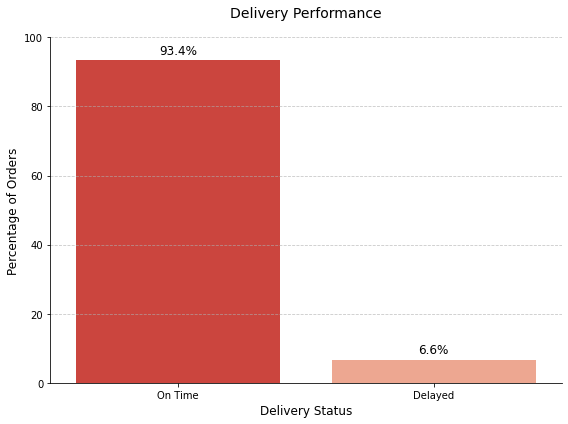

In [483]:
plt.figure(figsize=(8, 6))

# Create bar plot - convert series to DataFrame for seaborn
plot_data = delayed_orders.reset_index()
plot_data.columns = ['status', 'percentage']
ax = sns.barplot(data=plot_data, 
                 x='status', 
                 y='percentage',
                 palette='Reds_r')

# Customize labels
ax.set_xticklabels(['On Time', 'Delayed'])
ax.set_ylabel('Percentage of Orders', fontsize=12)
ax.set_xlabel('Delivery Status', fontsize=12)
plt.title('Delivery Performance', fontsize=14, pad=20)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
               (p.get_x() + p.get_width()/2., p.get_height()),
               ha='center', va='center', 
               xytext=(0, 10), 
               textcoords='offset points',
               fontsize=12)

# Improve styling
sns.despine()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100)  # Set y-axis to 0-100% scale

plt.tight_layout()
plt.show()

<div style="background-color:#FFF5E1; padding:20px 30px; 
    border-left: 5px groove #C80036;
    border-radius:10px; margin:40px 0;">
    <h2 style="font-size:24px;">📌 Findings:</h2>
    <ul style="font-size:16px;">
        <li>Only a very small percentage of the orders are delayed. We could suspect this is either due to efficient logistic shipping system or that the estimated delivery date for customers are very far away from the time it is created.</li>
    </ul>
</div>


<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
        3.2. Which states or cities have the highest delayed rates?
    </h4>
</div>

In [484]:
top_delayed_city = delivered_orders.loc[delivered_orders['delayed']==True]['customer_city'].value_counts().head(20).reset_index()
top_delayed_city.columns = ['city','delay_count']
top_delayed_city.head()

,city,delay_count
0,sao paulo,737
1,rio de janeiro,732
2,salvador,193
3,porto alegre,145
4,belo horizonte,144


In [485]:
def plot_barh_chart(df,x,y,xlabel,ylabel,title):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df, x=x, y=y, palette='Reds_r')
    plt.title(title,fontsize=15, weight='bold', pad=20)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='x', linestyle='--', alpha=0.7) 
    plt.tight_layout()
    plt.show()

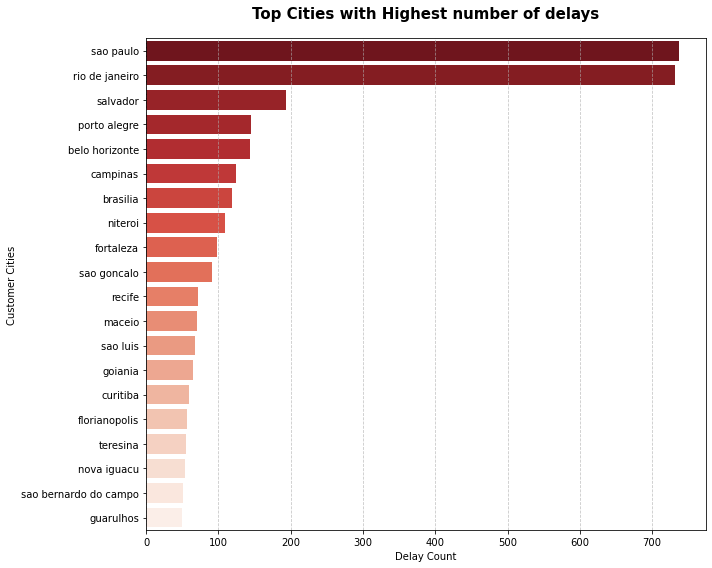

In [486]:
plot_barh_chart(top_delayed_city,'delay_count','city','Delay Count','Customer Cities','Top Cities with Highest number of delays')

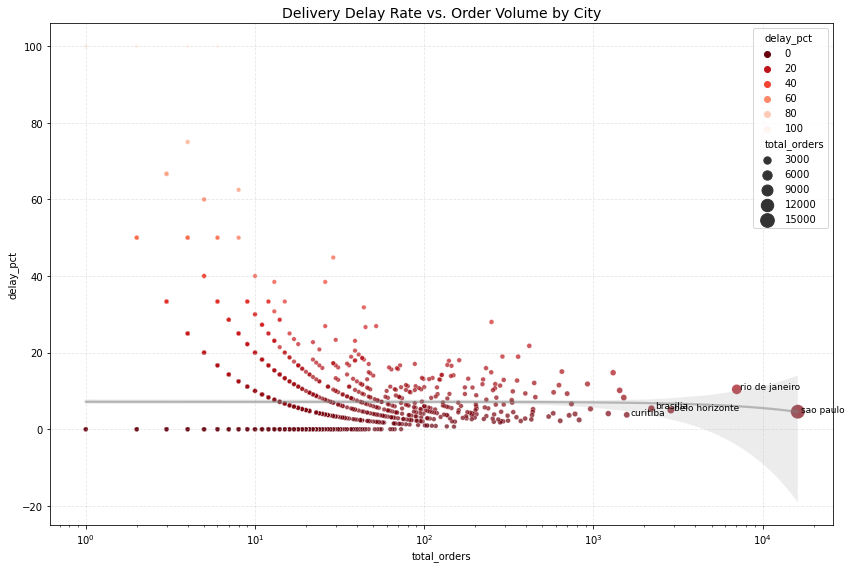

In [487]:
city_stats = (
    delivered_orders.groupby('customer_city')
    .agg(
        total_orders=('order_id', 'count'),
        delayed_orders=('delayed', 'sum')  # Assuming 'delayed' is boolean
    )
    .assign(delay_pct=lambda x: (x['delayed_orders'] / x['total_orders'] * 100).round(2))
    .reset_index()
    .sort_values('total_orders', ascending=False)
)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=city_stats,
    x='total_orders',
    y='delay_pct',
    hue='delay_pct',  # Color by delay rate
    size='total_orders',  # Size by order volume
    palette='Reds_r',    # Matches your theme
    alpha=0.7,
    sizes=(20, 200)      # Min/max bubble size
)

# 3. Highlight key cities (top 5 by order volume)
top_cities = city_stats.head(5)
for _, row in top_cities.iterrows():
    plt.text(
        row['total_orders'] * 1.05,  # Offset x-position
        row['delay_pct'],
        row['customer_city'],
        fontsize=9,
        ha='left'
    )

# 4. Customize
plt.title('Delivery Delay Rate vs. Order Volume by City', fontsize=14)
plt.xlabel('Total Orders (Log Scale)')  # Use log scale if skewed
plt.ylabel('Delay Rate (%)')
plt.yscale('linear')
plt.xscale('log')  # Helps if order counts vary widely
plt.grid(True, linestyle='--', alpha=0.3)

# 5. Add correlation line (if meaningful)
sns.regplot(
    data=city_stats,
    x='total_orders',
    y='delay_pct',
    scatter=False,
    color='gray',
    line_kws={'alpha': 0.5}
)

plt.tight_layout()
plt.show()

<div style="background-color:#FFF5E1; padding:20px 30px; 
    border-left: 5px groove #C80036;
    border-radius:10px; margin:40px 0;">
    <h2 style="font-size:24px;">📌 Findings:</h2>
    <ul style="font-size:16px;">
         <li style="margin-bottom: 6px;">Just look at the total number of delays per city doesn't give you a full picture. The delay count might be high but then it might be due to the total number of orders.</li>
            <li style="margin-bottom: 6px;">Using scatter-plot it can be seen that delayed rates are high at the cities with small volume of orders.
                The higher the volume of orders, the less likely it will be cancelled.
</li>
        <li style="margin-bottom: 6px;">We also had a lot of cities with very little delays that is almost 0%.
</li>
    </ul>
</div>


<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
        3.3. Do the delivery days and delays rate vary among product categories?
    </h4>
</div>

In [488]:
delivered_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'product_id', 'seller_id', 'price',
       'product_category_name', 'payment_type', 'payment_value',
       'payment_installments', 'product_category_name_english', 'review_id',
       'review_score', 'review_creation_date', 'geolocation_zip_code_prefix',
       'geolocation_lat', 'geolocation_lng', 'delay_period', 'delayed'],
      dtype='object')

In [489]:
top_delayed_category = delivered_orders.groupby('product_category_name_english')['delayed'].mean().sort_values(ascending=False).head(10)
top_delayed_category = top_delayed_category.reset_index() #to turn Series into DataFrame
top_delayed_category = top_delayed_category.sort_values(by='delayed',ascending=False)
top_delayed_category

,product_category_name_english,delayed
0,furniture_mattress_and_upholstery,0.125000
1,home_comfort_2,0.120000
2,audio,0.115702
3,fashion_male_clothing,0.087302
4,fashion_underwear_beach,0.087302
5,home_confort,0.085779
6,baby,0.080135
7,office_furniture,0.079732
8,books_technical,0.079245
9,furniture_living_room,0.078475


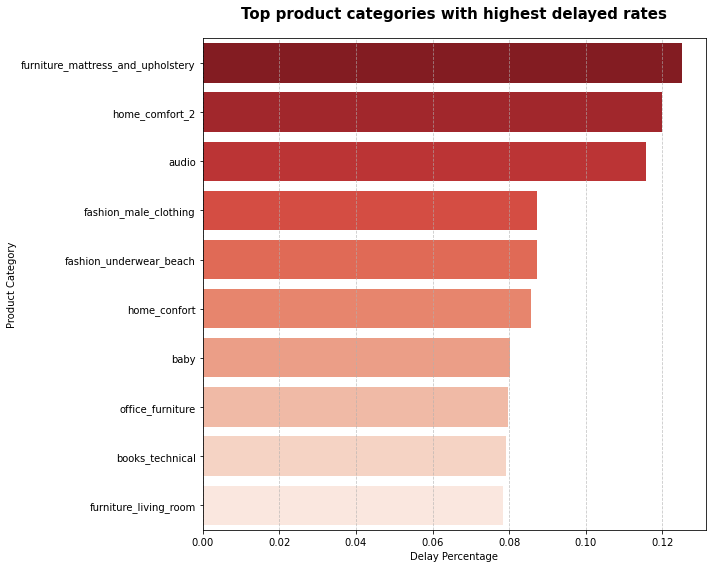

In [490]:
plot_barh_chart(top_delayed_category,'delayed','product_category_name_english','Delay Percentage','Product Category',
                'Top product categories with highest delayed rates')

In [491]:
delivered_orders['delivery_days']= (delivered_orders['order_delivered_customer_date']-delivered_orders['order_purchase_timestamp']).dt.days

In [492]:
top_delivery_categories = delivered_orders.groupby('product_category_name_english')['delivery_days'].median().nlargest(10)
bottom_delivery_categories = delivered_orders.groupby('product_category_name_english')['delivery_days'].median().nsmallest(10)
top_delivery_categories.head()

product_category_name_english
office_furniture         18.0
security_and_services    15.0
christmas_supplies       13.0
fashion_shoes            13.0
furniture_living_room    12.0
Name: delivery_days, dtype: float64

In [493]:
top_delivery_categories = top_delivery_categories.reset_index()
top_delivery_categories.columns=['product category','delivery days']

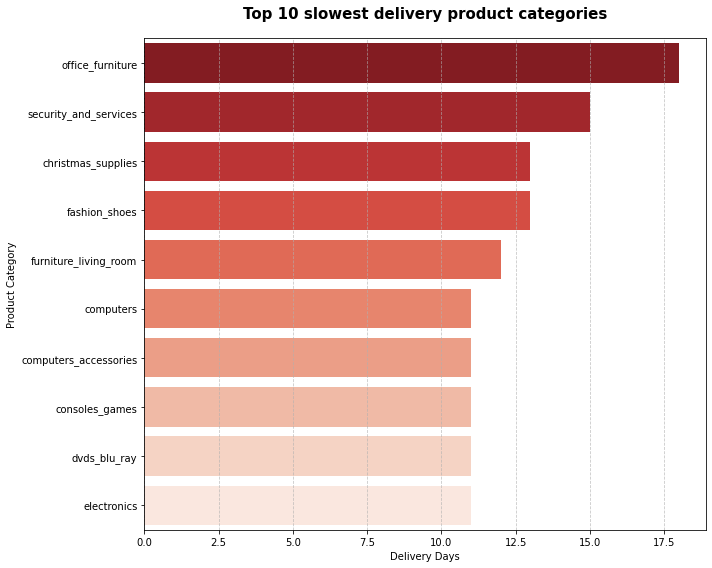

In [494]:
plot_barh_chart(top_delivery_categories,'delivery days','product category','Delivery Days','Product Category',
                'Top 10 slowest delivery product categories')

In [495]:
bottom_delivery_categories = bottom_delivery_categories.reset_index()
bottom_delivery_categories.columns=['product category','delivery days']

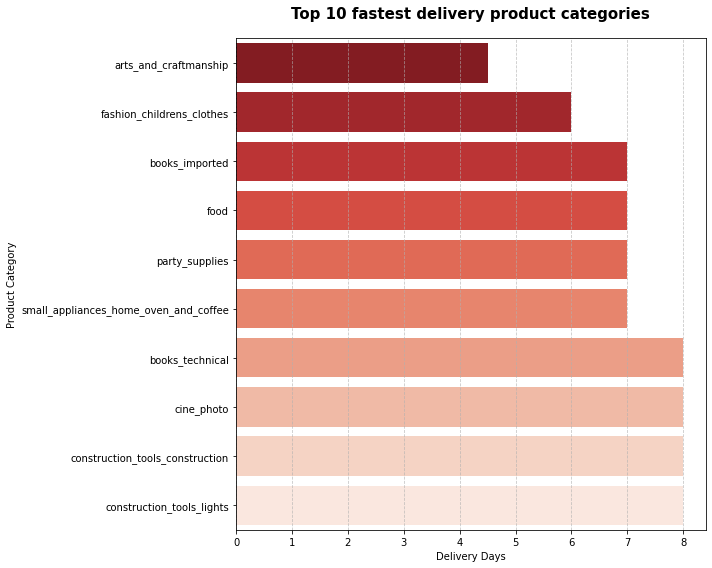

In [496]:
plot_barh_chart(bottom_delivery_categories,'delivery days','product category','Delivery Days','Product Category',
                'Top 10 fastest delivery product categories')

<div style="background-color:#FFF5E1; padding:20px 30px; 
    border-left: 5px groove #C80036;
    border-radius:10px; margin:40px 0;">
    <h2 style="font-size:24px;">📌 Findings:</h2>
    <ul style="font-size:16px;">
         <li style="margin-bottom: 6px;">Furniture/mattres and upholstery, home_comfor_2, and audio are the categories with the highest number of delays, however the highest percentage is only 12% which is not a big number.</li>
        <li style="margin-bottom: 6px;">When looking at total delivery days, office furnitures take more than 17 days from order created date until it reaches customer hand. Products in security and services group also come close at second place with total of 15 days.
</li>
        <li style="margin-bottom: 6px;">Top fatest delivered groups have the total delivery of less than 8 days, which are much shorter than the slowest delivery group. Arts and craftmanship is delivered the fastest with less than 5 days. Fashion children clothes also took less than a week to be delivered.
</li>
    </ul>
</div>

<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
        3.4. How does average delays change over time?
    </h4>
</div>

In [497]:
delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')
monthly_delay = delivered_orders.groupby('order_month')['delay_period'].mean().round()
monthly_delay = monthly_delay.reset_index()
monthly_delay.columns = ['order_month','average_delay_days']
monthly_delay.head()

,order_month,average_delay_days
0,2016-09,36.0
1,2016-10,-36.0
2,2016-12,-22.0
3,2017-01,-28.0
4,2017-02,-19.0


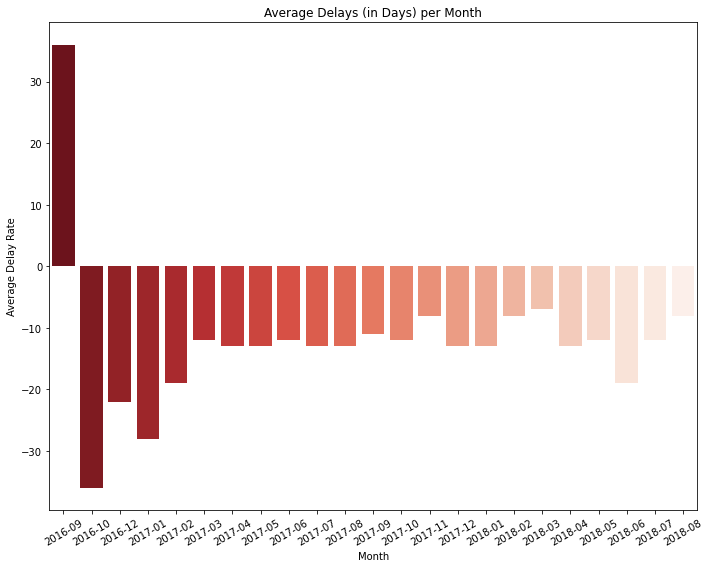

In [498]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=monthly_delay, 
    x='order_month', y='average_delay_days', palette='Reds_r')
plt.title('Average Delays (in Days) per Month')
plt.xlabel('Month')
plt.ylabel('Average Delay Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">It seems only in the beginning of 2016, 2016-09 that most of the delivery were delayed.
From that point, the average delivery rate was negative which means in most cases, the customers received the orders before estimated time.</li>
            <li style="margin-bottom: 6px;">We could dig in further to see what happened during that time frame compared to the rest.</li>
        </ul>
        </ul>
    </div>
    </p>
</div>

In [499]:
delivered_orders[delivered_orders['order_month']=='2016-09']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_creation_date,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,delay_period,delayed,delivery_days,order_month
68397,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,...,6916ca4502d6d3bfd39818759d55d536,1.0,2016-10-06 00:00:00,14600.0,-20.585829,-47.863559,36,True,54,2016-09


<div style="background-color:#FFF5E1; padding:15px 25px; border-left:5px solid #0C1844; margin:20px 0; border-radius:8px;">
    <p style="font-size:16px; color:#0C1844; margin:0;">
        <ul style="
            margin: 12px 0;
            padding-left: 20px;
        ">
            <li style="margin-bottom: 6px;">All the delayed orders from 2016-09 came from one order with a very high delay_period.</li>
            <li style="margin-bottom: 6px;">Since the data is quite skewed, we can say deduct that this case is an outlier for the time period.</li>
        </ul>
        </ul>
    </div>
    </p>
</div>

<div style="background-color:#FFF5E1; padding:20px 30px; 
    border-left: 5px groove #C80036;
    border-radius:10px; margin:40px 0;">
    <h2 style="font-size:24px;">📌 Findings:</h2>
    <ul style="font-size:16px;">
         <li style="margin-bottom: 6px;">The e-commerce site from 2016 onwards have always delivered faster than it is estimated to reach the customers. Only one month at the beginning that they had delayed orders which originated from one customer and one order only. From this we can conclude that the site on average always deliver faster than they promised.</li>
    </ul>
</div>

<div style="background-color:#0C1844; text-align:center; padding:20px; border-radius:10px; margin:40px 0;">
    <h4 style="color:#FFF5E1; font-size:20px; margin:0;">
        3.5. What is the average processing days between each stage of the order-to-delivered process?
    </h4>
</div>

In [503]:
orders['approval_time'] = orders['order_approved_at'] - orders['order_purchase_timestamp']
orders['waiting_time'] = orders['order_delivered_carrier_date'] - orders['order_approved_at']
orders['shipping_time'] = orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']
orders['total_time'] = orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
orders['estimated_time'] = orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']

In [504]:
time_columns = ['approval_time', 'waiting_time', 'shipping_time', 'total_time', 'estimated_time']

for col in time_columns:
    negatives = orders[orders[col] < pd.Timedelta(0)]
    print(f'{col}: {len(negatives)} negative values')

approval_time: 0 negative values
waiting_time: 1593 negative values
shipping_time: 58 negative values
total_time: 0 negative values
estimated_time: 0 negative values


In [505]:
orders = orders[orders['waiting_time'] >= pd.Timedelta(0)]
orders = orders[orders['shipping_time'] >= pd.Timedelta(0)]

In [508]:
time_columns = ['approval_time', 'waiting_time', 'shipping_time', 'total_time', 'estimated_time']

summary = pd.DataFrame({
    'mean': orders[time_columns].mean(),
    'median': orders[time_columns].median(),
    'std': orders[time_columns].std()
})

summary = summary.applymap(lambda x: pd.to_timedelta(x.round('s')))

summary

,mean,median,std
approval_time,0 days 09:47:45,0 days 00:20:28,0 days 19:31:35
waiting_time,2 days 21:33:12,1 days 20:57:54,3 days 12:19:53
shipping_time,9 days 05:46:20,7 days 01:43:16,8 days 15:26:06
total_time,12 days 13:07:17,10 days 06:06:44,9 days 11:12:03
estimated_time,23 days 20:26:15,23 days 06:17:14,8 days 20:06:29


In [510]:
summary = pd.DataFrame(
    {
        'median': [
            orders['approval_time'].median(),
            orders[orders['waiting_time'].notna()]['waiting_time'].median(),
            orders[orders['shipping_time'].notna()]['shipping_time'].median(),
            orders['total_time'].median(),
            orders['estimated_time'].median()
            
        ],
        'std':[
            orders['approval_time'].std(),
        orders[orders['waiting_time'].notna()]['waiting_time'].std(),
        orders[orders['shipping_time'].notna()]['shipping_time'].std(),
        orders['total_time'].std(),
        orders['estimated_time'].std()
        ]
    }, index=['Approval', 'Waiting', 'Shipping', 'Total', 'Estimated']
)
summary

,median,std
Approval,0 days 00:20:28,0 days 19:31:34.914350167
Waiting,1 days 20:57:54.500000,3 days 12:19:53.237338607
Shipping,7 days 01:43:16,8 days 15:26:06.237474586
Total,10 days 06:06:44,9 days 11:12:03.449044685
Estimated,23 days 06:17:13.500000,8 days 20:06:29.304633323


In [511]:
summary = summary.applymap(lambda x: pd.to_timedelta(x.round('s')))
summary

,median,std
Approval,0 days 00:20:28,0 days 19:31:35
Waiting,1 days 20:57:54,3 days 12:19:53
Shipping,7 days 01:43:16,8 days 15:26:06
Total,10 days 06:06:44,9 days 11:12:03
Estimated,23 days 06:17:14,8 days 20:06:29


In [512]:
summary['median_hours'] = summary['median'].dt.total_seconds() / 3600
summary['std_hours'] = summary['std'].dt.total_seconds() / 3600
summary['label'] = summary['median_hours'].apply(lambda h: f"{h:.0f}h\n({h/24:.1f}d)")
summary

,median,std,median_hours,std_hours,label
Approval,0 days 00:20:28,0 days 19:31:35,0.341111,19.526389,0h\n(0.0d)
Waiting,1 days 20:57:54,3 days 12:19:53,44.965000,84.331389,45h\n(1.9d)
Shipping,7 days 01:43:16,8 days 15:26:06,169.721111,207.435000,170h\n(7.1d)
Total,10 days 06:06:44,9 days 11:12:03,246.112222,227.200833,246h\n(10.3d)
Estimated,23 days 06:17:14,8 days 20:06:29,558.287222,212.108056,558h\n(23.3d)


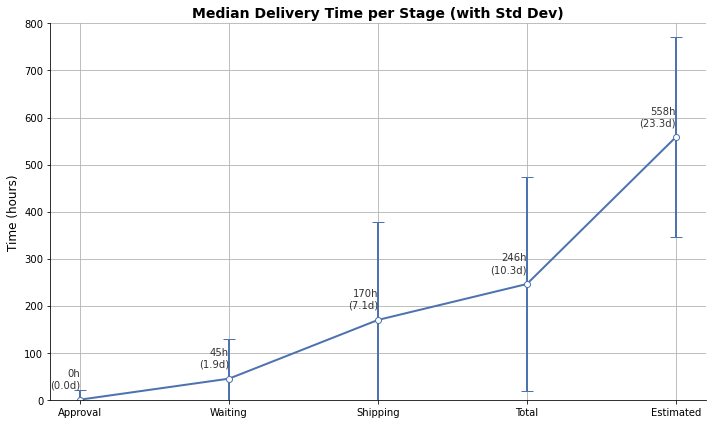

In [513]:
plt.figure(figsize=(10, 6))
plt.errorbar(summary.index, summary['median_hours'], yerr=summary['std_hours'],
             fmt='-o', color='#4C72B0', capsize=6, lw=2, markerfacecolor='white')

for i, (x, y) in enumerate(zip(summary.index, summary['median_hours'])):
    plt.text(x, y + 25, summary['label'].iloc[i], ha='right', fontsize=10, color='#333')

plt.title('Median Delivery Time per Stage (with Std Dev)', fontsize=14, weight='bold')
plt.ylabel('Time (hours)', fontsize=12)
plt.ylim(0, 800)
plt.grid(True)
plt.tight_layout()

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.show()

<div style="background-color:#FFF5E1; padding:20px 30px; 
    border-left: 5px groove #C80036;
    border-radius:10px; margin:40px 0;">
    <h2 style="font-size:24px;">📌 Findings:</h2>
    <ul style="font-size:16px;">
         <li style="margin-bottom: 6px;"><b>Approval Time:</b> The median time for Approval period is 20 minutes which means most of the orders are approved instantly and quick within the first hour of order create. This reflects the efficiency of the front-end system which allows users to approve quickly.</li>
         <li style="margin-bottom: 6px;"><b>Waiting Time:</b> Waiting time median is 1.9 days but the standard deviation is 84 hours which is quite high. This shows the difference between each seller when it comes to pick up the products from the warehouse. Some sellers might react swiftly, some might react slowly.</li>
        <li style="margin-bottom: 6px;"><b>Shipping Time:</b> The most dominant and time consuming stage. The median is 7 days but standard deviation can range up to 8 days (200 hours). This can happen due to the regional access and transporation methods. This section is the most potential bottleneck that we could focus on to resolve total delivery times.</li>
        <li style="margin-bottom: 6px;"><b>Total Time:</b> The total delivery time for customers have median of 10 days with standard deviation of 9 days. There is room for improvement as the e-commerce only focuses on domestic market and not international market thus the total delivery time could be shorter to match the overal international standards.</li>
        <li style="margin-bottom: 6px;"><b>Estimated Time:</b> From previous questions, we suspected the estimated time be set much further than actual delivery time becase we have very little delays from 2016/09 onwards. From the graph, we can see that estimated time is set almost double the actual shipping time.</li>
    </ul>
</div>